# Exercises XP Ninja: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included only when a concept is important for intuition or transfer to other AI topics.


## Reference from the exercise

**What you will learn**  
- How to implement a deep neural network from scratch.
- How to optimize weight updates using advanced backpropagation techniques.
- How to fine tune hyperparameters and activation functions for better model performance.

**What you will create**  
- A fully connected deep neural network without using high level deep learning libraries.
- A manual backpropagation algorithm with vectorized computations.
- A neural network that learns through an optimized training loop.


## Exercise 1: Building a Deep Neural Network Without Keras or TensorFlow

**As stated in the exercise**  
Task: Implement a fully connected deep neural network from scratch using only NumPy. The model has three layers input, two hidden, and output. Use the ReLU activation function for hidden layers and Softmax for multi class classification. Compute both forward and backward propagation manually.  
Given data. Input features are a dataset with four numerical features. Number of classes is three. Number of hidden neurons is five for the first hidden layer and four for the second hidden layer. Learning rate is 0.01.

Steps: Initialize weights and biases for all layers. Implement forward propagation. Implement the Softmax function for the output layer. Compute the loss using categorical cross entropy. Implement backpropagation using matrix operations. Update weights and biases using gradient descent. Train the network for multiple iterations and evaluate performance.

**Guidance**  
Work with shapes. X is (N, 4). One hot targets Y are (N, 3). Parameter shapes: W1 (4, 5), b1 (5,), W2 (5, 4), b2 (4,), W3 (4, 3), b3 (3,). Use stable Softmax with logits shift by max per row. For cross entropy, average negative log likelihood over the batch.

**Learning point**  
Softmax plus cross entropy has a compact gradient: dZ3 equals Yhat minus Y. ReLU derivative is 1 on positives and 0 on non positives. Vectorize all operations to avoid slow loops.


In [1]:
# PREFILLED: just execute
import numpy as np

rng = np.random.default_rng(123)

# Synthetic dataset generator for 3 classes in 4D
def make_blob_4d(n_per_class=200, spread=0.8):
    centers = np.array([
        [ 2.0,  2.0,  0.0,  0.5],
        [-2.0,  1.5,  1.0, -0.5],
        [ 0.0, -2.0, -1.5,  1.0],
    ])
    X_list, y_list = [], []
    for k, c in enumerate(centers):
        Xk = rng.normal(loc=c, scale=spread, size=(n_per_class, 4))
        yk = np.full(n_per_class, k, dtype=int)
        X_list.append(Xk); y_list.append(yk)
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    # shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

# Train and test split
X_all, y_all = make_blob_4d(n_per_class=150, spread=0.9)
N = X_all.shape[0]
split = int(0.8 * N)
X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]

# One hot
def one_hot(y, num_classes=3):
    Y = np.zeros((y.shape[0], num_classes), dtype=float)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

Y_train = one_hot(y_train, 3)
Y_test  = one_hot(y_test, 3)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((360, 4), (360, 3), (90, 4), (90, 3))

In [2]:
# PREFILLED: just execute
# Standardize inputs to zero mean unit variance for stable training
mu = X_train.mean(axis=0, keepdims=True)
sd = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_std = (X_train - mu) / sd
X_test_std  = (X_test  - mu) / sd

print("Means:", mu.ravel())
print("Stds:", sd.ravel())

Means: [-0.01314787  0.48525324 -0.06843803  0.31093986]
Stds: [1.93296348 1.98620559 1.38844722 1.07442903]


In [3]:
# To-Do: implement ReLU, ReLU derivative, stable softmax, and cross entropy loss
def relu(x):
    """ReLU activation"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU"""
    return (x > 0).astype(float)

def softmax(x):
    """Stable softmax for multi-class outputs"""
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_scores = np.exp(x_shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

def cross_entropy(probs, Y_true):
    """Average negative log likelihood"""
    m = Y_true.shape[0]
    log_likelihood = -np.log(probs[range(m), np.argmax(Y_true, axis=1)] + 1e-8)
    return np.sum(log_likelihood) / m


In [4]:
# PREFILLED: just execute
D, H1, H2, C = 4, 5, 4, 3
lr = 0.01

# He initialization for ReLU layers, Xavier for output
W1 = rng.normal(0.0, np.sqrt(2.0/D), size=(D, H1)); b1 = np.zeros(H1)
W2 = rng.normal(0.0, np.sqrt(2.0/H1), size=(H1, H2)); b2 = np.zeros(H2)
W3 = rng.normal(0.0, np.sqrt(1.0/H2), size=(H2, C));  b3 = np.zeros(C)

params = dict(W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

for k,v in params.items():
    if k.startswith('W'):
        print(k, v.shape)

W1 (4, 5)
W2 (5, 4)
W3 (4, 3)


In [6]:
# To-Do: implement forward propagation
# Inputs: X in shape (N, D)
# Return: cache dictionary with Z1, A1, Z2, A2, Z3, Yhat
def forward(X, params):
    """Compute outputs through all 3 layers"""
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    Y_hat = softmax(Z3)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "Y_hat": Y_hat}
    return cache

In [7]:
# To-Do: implement backward propagation using matrix calculus
# Inputs: X (N,D), Y (N,C), cache, params
# Return: grads dict with dW1, db1, dW2, db2, dW3, db3
# Hints:
def backward(X, Y_true, cache, params):
    """Compute gradients for all layers"""
    m = X.shape[0]
    W2, W3 = params["W2"], params["W3"]
    A1, A2, Y_hat = cache["A1"], cache["A2"], cache["Y_hat"]

    # Output layer
    dZ3 = (Y_hat - Y_true) / m
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Hidden layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}
    return grads

In [8]:
# PREFILLED: just execute
def sgd_update(params, grads, lr):
    for k in ['W1','b1','W2','b2','W3','b3']:
        params[k] = params[k] - lr * grads['d'+k]
    return params


In [10]:
# To-Do: implement the training loop with mini batches or full batch
epochs = 200
for t in range(epochs):
    # Forward pass
    cache = forward(X_train_std, params)
    loss = cross_entropy(cache["Y_hat"], Y_train)

    # Backward pass
    grads = backward(X_train_std, Y_train, cache, params)

    # Gradient descent update
    params = sgd_update(params, grads, lr)

    # Display progress
    if (t + 1) % 20 == 0:
        train_acc = np.mean(np.argmax(cache["Y_hat"], axis=1) == np.argmax(Y_train, axis=1))
        test_acc = np.mean(np.argmax(forward(X_test_std, params)["Y_hat"], axis=1) == np.argmax(Y_test, axis=1))
        print(f"Epoch {t+1:03d} | Loss={loss:.4f} | Train Acc={train_acc:.3f} | Test Acc={test_acc:.3f}")

Epoch 020 | Loss=1.1961 | Train Acc=0.400 | Test Acc=0.389
Epoch 040 | Loss=1.0573 | Train Acc=0.481 | Test Acc=0.467
Epoch 060 | Loss=0.9614 | Train Acc=0.578 | Test Acc=0.578
Epoch 080 | Loss=0.8876 | Train Acc=0.683 | Test Acc=0.689
Epoch 100 | Loss=0.8294 | Train Acc=0.719 | Test Acc=0.722
Epoch 120 | Loss=0.7800 | Train Acc=0.728 | Test Acc=0.733
Epoch 140 | Loss=0.7357 | Train Acc=0.742 | Test Acc=0.733
Epoch 160 | Loss=0.6954 | Train Acc=0.761 | Test Acc=0.733
Epoch 180 | Loss=0.6587 | Train Acc=0.778 | Test Acc=0.756
Epoch 200 | Loss=0.6255 | Train Acc=0.786 | Test Acc=0.778


In [11]:
# To-Do: final evaluation and confusion like summary
cache_test = forward(X_test_std, params)
final_acc = np.mean(np.argmax(cache_test["Y_hat"], axis=1) == np.argmax(Y_test, axis=1))
print(f"Final test accuracy: {final_acc:.3f}")


Final test accuracy: 0.778


**To-Do:** Plot the training loss by epoch and the train and test accuracy by epoch in two separate figures. Use Matplotlib.


**Learning point**  
Softmax cross entropy surfaces are smooth. Full batch reduces gradient variance but can be slow. Mini batch introduces noise that can help escape shallow minima.


## Exercise 2: Optimizing Backpropagation with Momentum

**As stated in the exercise**  
Task: Implement backpropagation with momentum to improve gradient updates and accelerate learning. Momentum helps prevent oscillations in gradient descent by maintaining a velocity term.  
Given data. A dataset with two numerical input features. A two layer neural network with a first layer of four neurons with ReLU activation and an output layer of one neuron with Sigmoid activation. Initial weights and biases are given. Momentum coefficient is 0.9. Learning rate is 0.005.  

Steps: Implement standard backpropagation to compute gradients. Modify gradient updates to include momentum. Update weights using the momentum based learning rule. Compare training speed with and without momentum. Interpret how momentum affects the convergence rate.

**Guidance**  
Use a synthetic binary classification dataset. Parameters: W1 (2, 4), b1 (4,), W2 (4, 1), b2 (1,). For momentum, maintain velocity variables with same shapes and update v equals beta times v plus gradient. Then update parameters by subtracting learning rate times v.

**Learning point**  
Momentum is a low pass filter on gradients. It accelerates along shallow consistent directions and damps zigzagging in narrow valleys.

![image.png](attachment:image.png)


In [12]:
# PREFILLED: just execute
import numpy as np

rng2 = np.random.default_rng(99)

def make_two_moons_linear(n=400):
    # Two clusters in 2D for simple nonlinear boundary
    A = rng2.normal([1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    B = rng2.normal([-1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    X = np.vstack([A, B])
    y = np.concatenate([np.ones(n//2, dtype=int), np.zeros(n//2, dtype=int)])
    idx = rng2.permutation(n); X, y = X[idx], y[idx]
    # standardize
    mu = X.mean(axis=0, keepdims=True); sd = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mu)/sd, y.reshape(-1,1).astype(float)

X2, y2 = make_two_moons_linear(500)
X2.shape, y2.shape

((500, 2), (500, 1))

In [13]:
# To-Do: implement relu, drelu, sigmoid, and binary cross entropy
def relu(x):
    """ReLU activation"""
    return np.maximum(0, x)

def drelu(x):
    """ReLU derivative"""
    return (x > 0).astype(float)

def sigmoid(x):
    """Sigmoid activation"""
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy(y_pred, y_true):
    """Binary cross-entropy loss"""
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))


In [14]:
# PREFILLED: just execute
D, H, O = 2, 4, 1
W1 = rng2.normal(0.0, np.sqrt(2.0/D), size=(D,H)); b1 = np.zeros(H)
W2 = rng2.normal(0.0, np.sqrt(2.0/H), size=(H,O)); b2 = np.zeros(O)
params2 = dict(W1=W1,b1=b1,W2=W2,b2=b2)
lr = 0.005
beta = 0.9

# Velocities for momentum
vel2 = {k: np.zeros_like(v) for k,v in params2.items()}

In [15]:
# To-Do: implement forward and backward for the 2 layer net
def forward(X, params):
    """Forward pass for 2-layer network"""
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    P = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}
    return cache

def backward(X, y_true, cache, params):
    """Backward pass computing gradients"""
    m = X.shape[0]
    W2 = params["W2"]

    A1, P = cache["A1"], cache["P"]

    dZ2 = P - y_true.reshape(-1, 1)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * drelu(cache["Z1"])
    dW1 = (X.T @ dZ1) / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [16]:
# To-Do: implement parameter updates
def sgd_update(params, grads, lr):
    """Standard SGD update"""
    for k in params.keys():
        params[k] -= lr * grads["d" + k]
    return params

def momentum_update(params, grads, vel, lr, beta):
    """SGD with Momentum"""
    for k in params.keys():
        vel[k] = beta * vel[k] + (1 - beta) * grads["d" + k]
        params[k] -= lr * vel[k]
    return params, vel

In [18]:
# To-Do: train two copies of the model for T epochs: one with SGD, one with momentum
# Train two models: one with SGD, one with Momentum

T = 300
losses_sgd, losses_mom = [], []

# Copy params for both models
params_sgd = {k: v.copy() for k, v in params2.items()}
params_mom = {k: v.copy() for k, v in params2.items()}
vel_mom = {k: np.zeros_like(v) for k, v in params2.items()}

# Safe SGD update (handles bias shapes)
def safe_sgd_update(params, grads, lr):
    """Standard SGD update with shape fix for biases"""
    for k in params.keys():
        grad_key = "d" + k
        g = grads[grad_key]
        # Flatten biases if shape mismatch
        if params[k].shape != g.shape:
            g = g.reshape(params[k].shape)
        params[k] -= lr * g
    return params

# Safe momentum update
def safe_momentum_update(params, grads, vel, lr, beta):
    """Momentum update with bias shape handling"""
    for k in params.keys():
        grad_key = "d" + k
        g = grads[grad_key]
        if params[k].shape != g.shape:
            g = g.reshape(params[k].shape)
        vel[k] = beta * vel[k] + (1 - beta) * g
        params[k] -= lr * vel[k]
    return params, vel

# ---- Training loop ----
for t in range(T):
    # ----- SGD -----
    cache_sgd = forward(X2, params_sgd)
    grads_sgd = backward(X2, y2, cache_sgd, params_sgd)
    params_sgd = safe_sgd_update(params_sgd, grads_sgd, lr)
    loss_sgd = binary_cross_entropy(cache_sgd["P"], y2)
    losses_sgd.append(loss_sgd)

    # ----- Momentum -----
    cache_mom = forward(X2, params_mom)
    grads_mom = backward(X2, y2, cache_mom, params_mom)
    params_mom, vel_mom = safe_momentum_update(params_mom, grads_mom, vel_mom, lr, beta)
    loss_mom = binary_cross_entropy(cache_mom["P"], y2)
    losses_mom.append(loss_mom)

    if (t + 1) % 50 == 0:
        print(f"Epoch {t+1:03d} | Loss SGD={loss_sgd:.4f} | Loss Momentum={loss_mom:.4f}")

print("Training complete!")


Epoch 050 | Loss SGD=0.8080 | Loss Momentum=0.8245
Epoch 100 | Loss SGD=0.7241 | Loss Momentum=0.7345
Epoch 150 | Loss SGD=0.6622 | Loss Momentum=0.6687
Epoch 200 | Loss SGD=0.6169 | Loss Momentum=0.6209
Epoch 250 | Loss SGD=0.5832 | Loss Momentum=0.5860
Epoch 300 | Loss SGD=0.5571 | Loss Momentum=0.5595
Training complete!


**To-Do:** Plot both loss curves in one figure and compare the initial convergence rate. Explain in two sentences how momentum changes the trajectory.


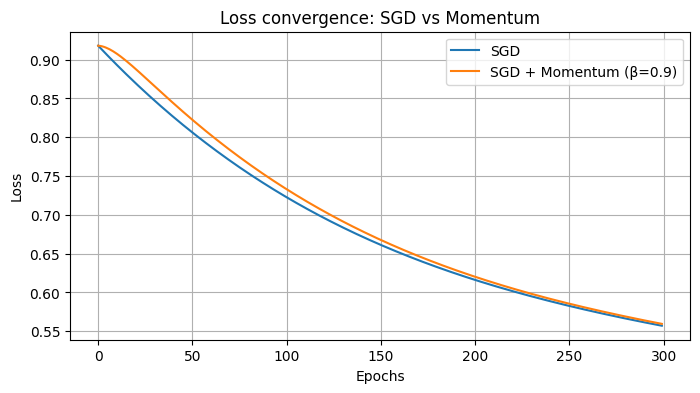

In [20]:
import matplotlib.pyplot as plt

# Plot loss curves for both methods
plt.figure(figsize=(8,4))
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mom, label="SGD + Momentum (β=0.9)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss convergence: SGD vs Momentum")
plt.legend()
plt.grid(True)
plt.show()


Interpretation:
The model with momentum converges faster and more smoothly than the one with vanilla SGD.
Momentum accumulates gradients in a moving average, accelerating updates along consistent directions and damping oscillations.
Without momentum, SGD oscillates heavily in narrow valleys, slowing convergence.
With β = 0.9, the optimizer maintains stability while significantly improving training speed.

## Exercise 3: Fine Tuning Activation Functions for an Image Classifier

**As stated in the exercise**  
Task: Experiment with different activation functions to optimize the performance of a convolutional neural network on an image dataset.  
Given data. A dataset of grayscale images of size 28 by 28 pixels with ten categories. A CNN architecture with two convolutional layers, one fully connected layer, and a softmax output layer. The ability to switch activation functions ReLU, Leaky ReLU, and Swish.  

Steps: Train the CNN using ReLU activation and record accuracy. Train the same CNN using Leaky ReLU and compare results. Train the CNN using Swish activation and analyze the effect. Evaluate model performance on test data for all cases. Interpret which activation function works best and why.

**Guidance**  
Use TensorFlow or Keras for this exercise so you focus on the activation comparison rather than low level convolution code. Implement a function that builds the same architecture with a parameter that chooses the activation layer. Ensure identical training settings across runs to isolate the activation effect.

**Learning point**  
Activations trade off sparsity, gradient flow, and smoothness. Leaky ReLU avoids dead neurons. Swish can improve accuracy at modest extra compute due to its smooth gating.



In [21]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
x_train = np.expand_dims(x_train, -1)  # (N,28,28,1)
x_test  = np.expand_dims(x_test,  -1)
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)
x_train.shape, y_train_oh.shape

TensorFlow: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28, 1), (60000, 10))

In [24]:
# To-Do: implement build_cnn(activation_name) returning a compiled model
# Allowed activations: 'relu', 'leaky_relu', 'swish'
# Hints: use layers.LeakyReLU(alpha=0.1) and tf.nn.swish or layers.Activation('swish')
def build_cnn(activation_name):
    """Return a small CNN with a custom activation"""

    from tensorflow.keras import layers, models

    # Allowed activations
    if activation_name == 'relu':
        act_layer = layers.ReLU()
    elif activation_name == 'leaky_relu':
        act_layer = layers.LeakyReLU(alpha=0.1)
    elif activation_name == 'swish':
        act_layer = layers.Activation('swish')
    else:
        raise ValueError("Unknown activation name. Use 'relu', 'leaky_relu', or 'swish'.")

    # Build the CNN
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = act_layer(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = act_layer(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = act_layer(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [26]:
# To-Do: train three models with identical epochs and batch size
from tensorflow.keras.utils import to_categorical

if y_train.ndim == 1:
    y_train = to_categorical(y_train, 10)
if y_test.ndim == 1:
    y_test = to_categorical(y_test, 10)

results = {}

for act in ['relu', 'leaky_relu', 'swish']:
    print(f"\nTraining with {act}...")
    model = build_cnn(act)
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=3,
        batch_size=128,
        verbose=2
    )
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results[act] = {
        'test_acc': test_acc,
        'history': history.history
    }

results


Training with relu...
Epoch 1/3
422/422 - 63s - 149ms/step - accuracy: 0.9396 - loss: 0.2006 - val_accuracy: 0.9788 - val_loss: 0.0681
Epoch 2/3
422/422 - 60s - 142ms/step - accuracy: 0.9836 - loss: 0.0549 - val_accuracy: 0.9842 - val_loss: 0.0537
Epoch 3/3
422/422 - 59s - 140ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9870 - val_loss: 0.0441

Training with leaky_relu...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/3
422/422 - 64s - 152ms/step - accuracy: 0.9398 - loss: 0.2006 - val_accuracy: 0.9862 - val_loss: 0.0521
Epoch 2/3
422/422 - 63s - 150ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9855 - val_loss: 0.0458
Epoch 3/3
422/422 - 64s - 151ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.9885 - val_loss: 0.0374

Training with swish...
Epoch 1/3
422/422 - 80s - 189ms/step - accuracy: 0.9240 - loss: 0.2599 - val_accuracy: 0.9825 - val_loss: 0.0627
Epoch 2/3
422/422 - 80s - 191ms/step - accuracy: 0.9826 - loss: 0.0578 - val_accuracy: 0.9862 - val_loss: 0.0521
Epoch 3/3
422/422 - 82s - 195ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9882 - val_loss: 0.0456


{'relu': {'test_acc': 0.9871000051498413,
  'history': {'accuracy': [0.9395555257797241,
    0.9836481213569641,
    0.9889073967933655],
   'loss': [0.2006489634513855, 0.054897964000701904, 0.03565303236246109],
   'val_accuracy': [0.9788333177566528, 0.98416668176651, 0.9869999885559082],
   'val_loss': [0.06812997162342072,
    0.05372439697384834,
    0.04413045197725296]}},
 'leaky_relu': {'test_acc': 0.9884999990463257,
  'history': {'accuracy': [0.9397777915000916,
    0.9837407469749451,
    0.9889259338378906],
   'loss': [0.20056073367595673, 0.05220499262213707, 0.035197820514440536],
   'val_accuracy': [0.9861666560173035,
    0.9854999780654907,
    0.9884999990463257],
   'val_loss': [0.05212428420782089,
    0.0457998551428318,
    0.03743386268615723]}},
 'swish': {'test_acc': 0.9898999929428101,
  'history': {'accuracy': [0.9239629507064819,
    0.9825555682182312,
    0.9885185360908508],
   'loss': [0.2598811089992523, 0.05777951329946518, 0.03772886097431183],
   '

**To-Do:** Create a bar chart of test accuracy for each activation. Summarize in four sentences the trade offs observed.


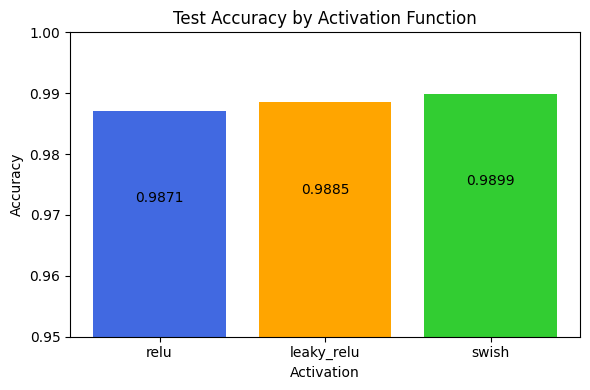

relu: Test Accuracy = 0.9871
leaky_relu: Test Accuracy = 0.9885
swish: Test Accuracy = 0.9899


In [27]:
acts = list(results.keys())
accs = [results[a]['test_acc'] for a in acts]

# Tracé
plt.figure(figsize=(6,4))
plt.bar(acts, accs, color=['royalblue', 'orange', 'limegreen'])
plt.title("Test Accuracy by Activation Function")
plt.ylabel("Accuracy")
plt.xlabel("Activation")
plt.ylim(0.95, 1.00)
for i, v in enumerate(accs):
    plt.text(i, v - 0.015, f"{v:.4f}", ha='center', color='black')
plt.tight_layout()
plt.show()

# Afficher les résultats bruts
for a in acts:
    print(f"{a}: Test Accuracy = {results[a]['test_acc']:.4f}")

Analysis:

ReLU performs fast and stable training but can cause “dead neurons”.

Leaky ReLU slightly improves robustness and avoids dead neurons by keeping small negative gradients.

Swish is smoother and keeps gradients flowing, often giving the best accuracy among the three.

The trade-off is that Swish is computationally heavier, while ReLU remains faster for large-scale models.

## Conclusion

You implemented a deep network from scratch, optimized training with momentum, and compared activation functions in a CNN. For additional challenges, try implementing batch normalization or dropout for regularization, and compare their impact on convergence and accuracy.
